In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# =========================
# CONFIG
# =========================
TS = 0.07
TIME_STEPS = 20
BATCH_SIZE = 32
EPOCHS = 20

DATA_PATH = "./Data/Datasets.xlsx"

TARGET_NAME = "Theta"
PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]


Epoch 1 | Ld=9.1571 | Lf=1.3942
Epoch 2 | Ld=3.5939 | Lf=0.5858
Epoch 3 | Ld=2.2007 | Lf=0.4892
Epoch 4 | Ld=1.7921 | Lf=0.4739
Epoch 5 | Ld=1.5423 | Lf=0.4482
Epoch 6 | Ld=1.3649 | Lf=0.4153
Epoch 7 | Ld=1.2464 | Lf=0.3712
Epoch 8 | Ld=1.1539 | Lf=0.3153
Epoch 9 | Ld=1.0688 | Lf=0.3107
Epoch 10 | Ld=1.0301 | Lf=0.2958
Epoch 11 | Ld=1.0183 | Lf=0.2905
Epoch 12 | Ld=0.9868 | Lf=0.2985
Epoch 13 | Ld=0.9083 | Lf=0.2559
Epoch 14 | Ld=0.8680 | Lf=0.2429
Epoch 15 | Ld=0.8248 | Lf=0.2270
Epoch 16 | Ld=0.8025 | Lf=0.2189
Epoch 17 | Ld=0.7755 | Lf=0.2168
Epoch 18 | Ld=0.7418 | Lf=0.2118
Epoch 19 | Ld=0.7258 | Lf=0.2083
Epoch 20 | Ld=0.7027 | Lf=0.2071
Train_1 | R2 dtarget: 0.7772 | R2 Theta: -1.5520
Train_2 | R2 dtarget: 0.8053 | R2 Theta: -0.2495
Val_1 | R2 dtarget: 0.5648 | R2 Theta: -1.5798
Val_2 | R2 dtarget: 0.7777 | R2 Theta: 0.2248
Test_1 | R2 dtarget: 0.4120 | R2 Theta: -13.4527
Test_2 | R2 dtarget: 0.4839 | R2 Theta: -8.9912
LSG_1 | R2 dtarget: 0.3479 | R2 Theta: 0.6100
LSG_2 | R2 dta

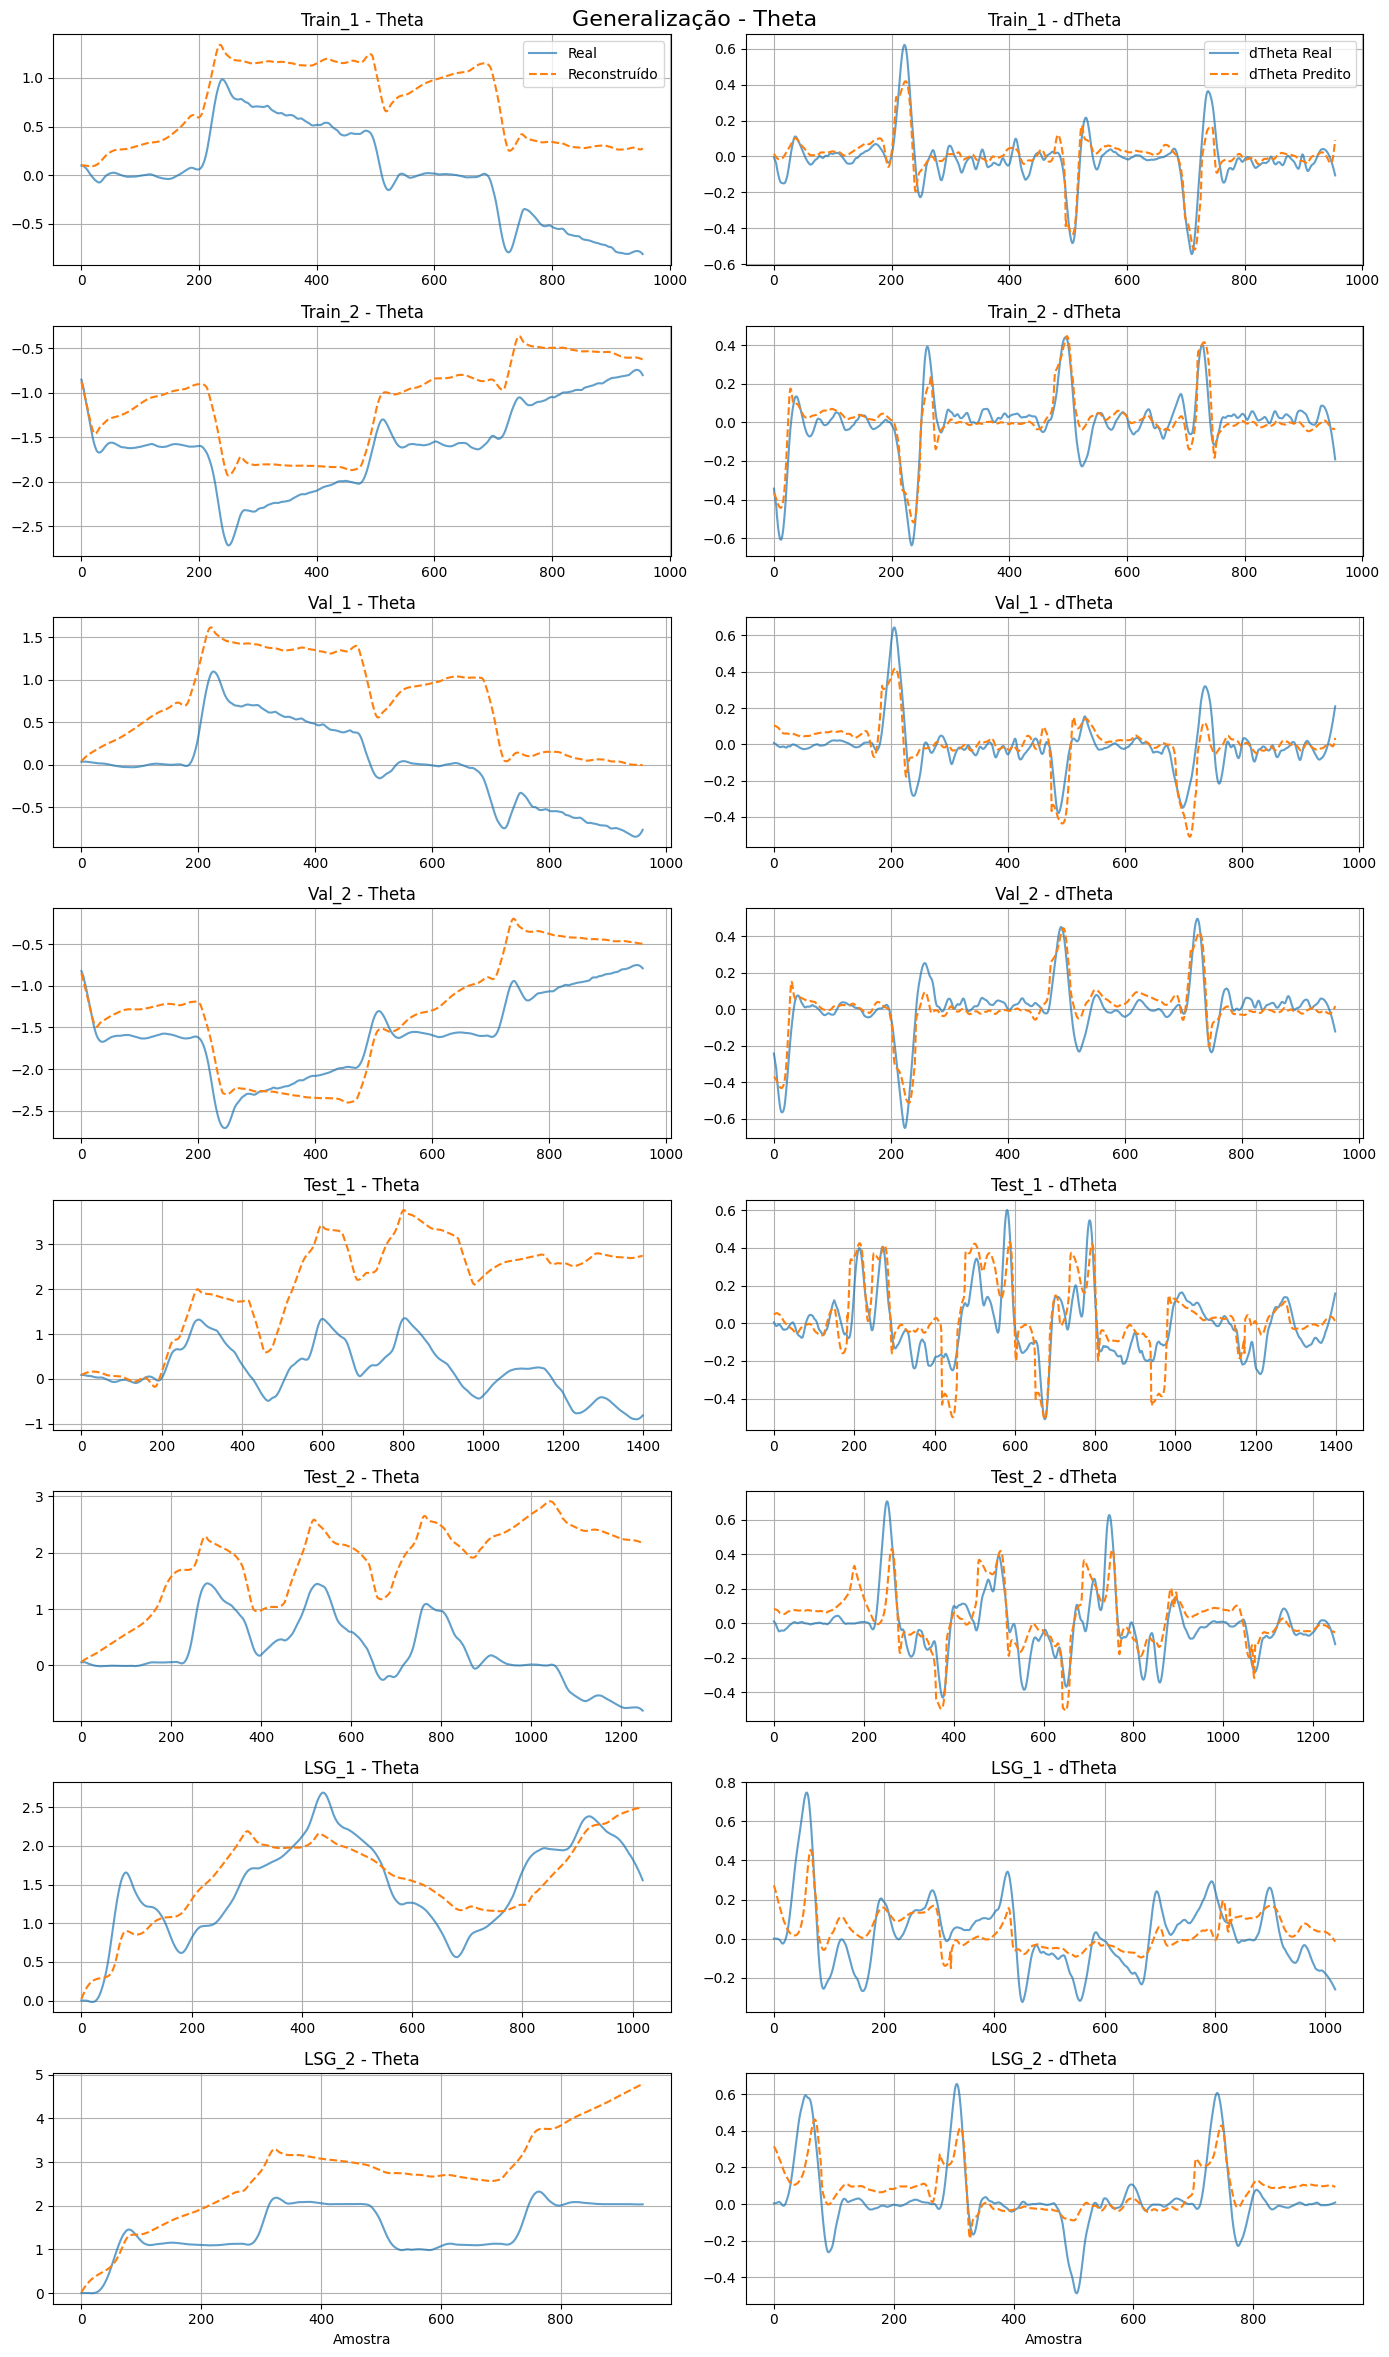

In [2]:

# =========================
# LOAD TREINO
# =========================
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name="Train_1"),
               pd.read_excel(DATA_PATH, sheet_name="Train_2")])

Target = df[TARGET_NAME].values
dTarget = df[f"d{TARGET_NAME}"].values
Wd = df["Wd"]
We = df["We"]
pred_raw = df[PREDICTORS].values

# =========================
# NORMALIZAÇÃO
# =========================
pred_mean = pred_raw.mean(axis=0)
pred_std = pred_raw.std(axis=0) + 1e-8
pred_raw = (pred_raw - pred_mean) / pred_std

mean = dTarget.mean()
std = dTarget.std() + 1e-8
y_raw = (dTarget - mean) / std

# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(pred_raw, y_raw, TIME_STEPS)

# =========================
# MODELO (dinâmico)
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, len(PREDICTORS))),
    tf.keras.layers.SimpleRNN(32, activation='tanh'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

# =========================
# TREINO
# =========================
# =========================
# HIPERPARÂMETROS PIRNN
# =========================
Ld = 1.0
Lp = 0.1  

optimizer = tf.keras.optimizers.Adam(1e-3)

# =========================
# TRAIN STEP
# =========================
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):
    return (R / (2 * L)) * (Wd - We)

@tf.function
def train_step(model, optimizer, x, dy, Wd, We):

    alpha = 2.0
    weights = 1 + alpha * tf.abs(dy)

    with tf.GradientTape() as tape:

        dy_pred = model(x, training=True)

        # 🔹 LOSS DADOS
        data_loss = tf.reduce_mean(weights * tf.square(dy_pred - dy))

        # 🔹 MODELO CINEMÁTICO
        dtheta_cin = (R / (2.0 * L)) * (Wd - We)
        dtheta_cin = tf.expand_dims(dtheta_cin, axis=1)

        # 🔹 NORMALIZAÇÃO
        physics_norm = (dtheta_cin - mean) / std

        # 🔹 LOSS FÍSICA
        physics_loss = tf.reduce_mean(tf.square(dy_pred - physics_norm))

        loss = Ld * data_loss + Lp * physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return data_loss, physics_loss

def create_sequences_full(pred, target, theta, Wd, We, time_steps):
    Xs, ys, thetas, wds, wes = [], [], [], [], []

    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
        thetas.append(theta[i:i+time_steps])
        wds.append(Wd[i+time_steps])  
        wes.append(We[i+time_steps])

    return (
        np.array(Xs),
        np.array(ys),
        np.array(thetas),
        np.array(wds),
        np.array(wes),
    )
      
X, y, theta_seq, Wd_seq, We_seq = create_sequences_full(
    pred_raw, y_raw, Target, Wd.values, We.values, TIME_STEPS
)
for epoch in range(EPOCHS):

    loss_d_epoch = []
    loss_f_epoch = []

    for i in range(0, len(X), BATCH_SIZE):

        xb = X[i:i+BATCH_SIZE]
        yb = y[i:i+BATCH_SIZE]
        tb = theta_seq[i:i+BATCH_SIZE]
        wd = Wd_seq[i:i+BATCH_SIZE]
        we = We_seq[i:i+BATCH_SIZE]
        

        ld, lf = train_step(
            model,
            optimizer,
            tf.convert_to_tensor(xb, tf.float32),
            tf.convert_to_tensor(yb.reshape(-1,1), tf.float32),
            tf.convert_to_tensor(wd, tf.float32),
            tf.convert_to_tensor(we, tf.float32),
)

        loss_d_epoch.append(ld.numpy())
        loss_f_epoch.append(lf.numpy())

    print(f"Epoch {epoch+1} | Ld={np.mean(loss_d_epoch):.4f} | Lf={np.mean(loss_f_epoch):.4f}")

# =========================
# FIGURA GERAL
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df = pd.read_excel(DATA_PATH, sheet_name=title)

    Target = df[TARGET_NAME].values
    dTarget = df[f"d{TARGET_NAME}"].values

    pred_raw = df[PREDICTORS].values

    # normalização treino
    pred_raw = (pred_raw - pred_mean) / pred_std
    y_raw = (dTarget - mean) / std

    X_test, y_test = create_sequences(pred_raw, y_raw, TIME_STEPS)

    # predição
    y_pred = model.predict(X_test, verbose=0)

    y_pred = y_pred * std + mean
    y_true = y_test * std + mean

    # =========================
    # RECONSTRUÇÃO (se for derivada)
    # =========================
    Target_true = Target[TIME_STEPS:]

    Target_rec = np.zeros_like(y_pred.flatten())

    y_pred_flat = y_pred.flatten()
    Target_rec = Target_true[0] + np.cumsum(y_pred_flat * TS)

    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Target_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Target_rec, label="Reconstruído", linestyle='--')

    axs[i, 0].set_title(f"{title} - {TARGET_NAME}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(y_true, label=f"d{TARGET_NAME} Real", alpha=0.7)
    axs[i, 1].plot(y_pred, label=f"d{TARGET_NAME} Predito", linestyle='--')

    axs[i, 1].set_title(f"{title} - d{TARGET_NAME}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
    r2_dtarget = r2_score(y_true.flatten(), y_pred.flatten())
    r2_target  = r2_score(Target_true.flatten(), Target_rec.flatten())
    print(f"{title} | R2 dtarget: {r2_dtarget:.4f} | R2 Theta: {r2_target:.4f}")
    
axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET_NAME}", fontsize=16)
plt.tight_layout()
plt.show()

Epoch 1/20

49/49 [==============================] - 2s 11ms/step - loss: 1.3248 - val_loss: 0.2396
Epoch 2/20
49/49 [==============================] - 0s 5ms/step - loss: 0.5010 - val_loss: 0.2784
Epoch 3/20
49/49 [==============================] - 0s 7ms/step - loss: 0.3752 - val_loss: 0.3290
Epoch 4/20
49/49 [==============================] - 0s 6ms/step - loss: 0.2954 - val_loss: 0.4374
Epoch 5/20
49/49 [==============================] - 0s 6ms/step - loss: 0.2547 - val_loss: 0.3109
Epoch 6/20
49/49 [==============================] - 0s 5ms/step - loss: 0.2151 - val_loss: 0.2417
Epoch 7/20
49/49 [==============================] - 0s 6ms/step - loss: 0.1769 - val_loss: 0.3189
Epoch 8/20
49/49 [==============================] - 0s 6ms/step - loss: 0.1563 - val_loss: 0.2918
Epoch 9/20
49/49 [==============================] - 0s 6ms/step - loss: 0.1482 - val_loss: 0.5363
Epoch 10/20
49/49 [==============================] - 0s 7ms/step - loss: 0.1487 - val_loss: 0.3520
Epoch 11/20
49/49

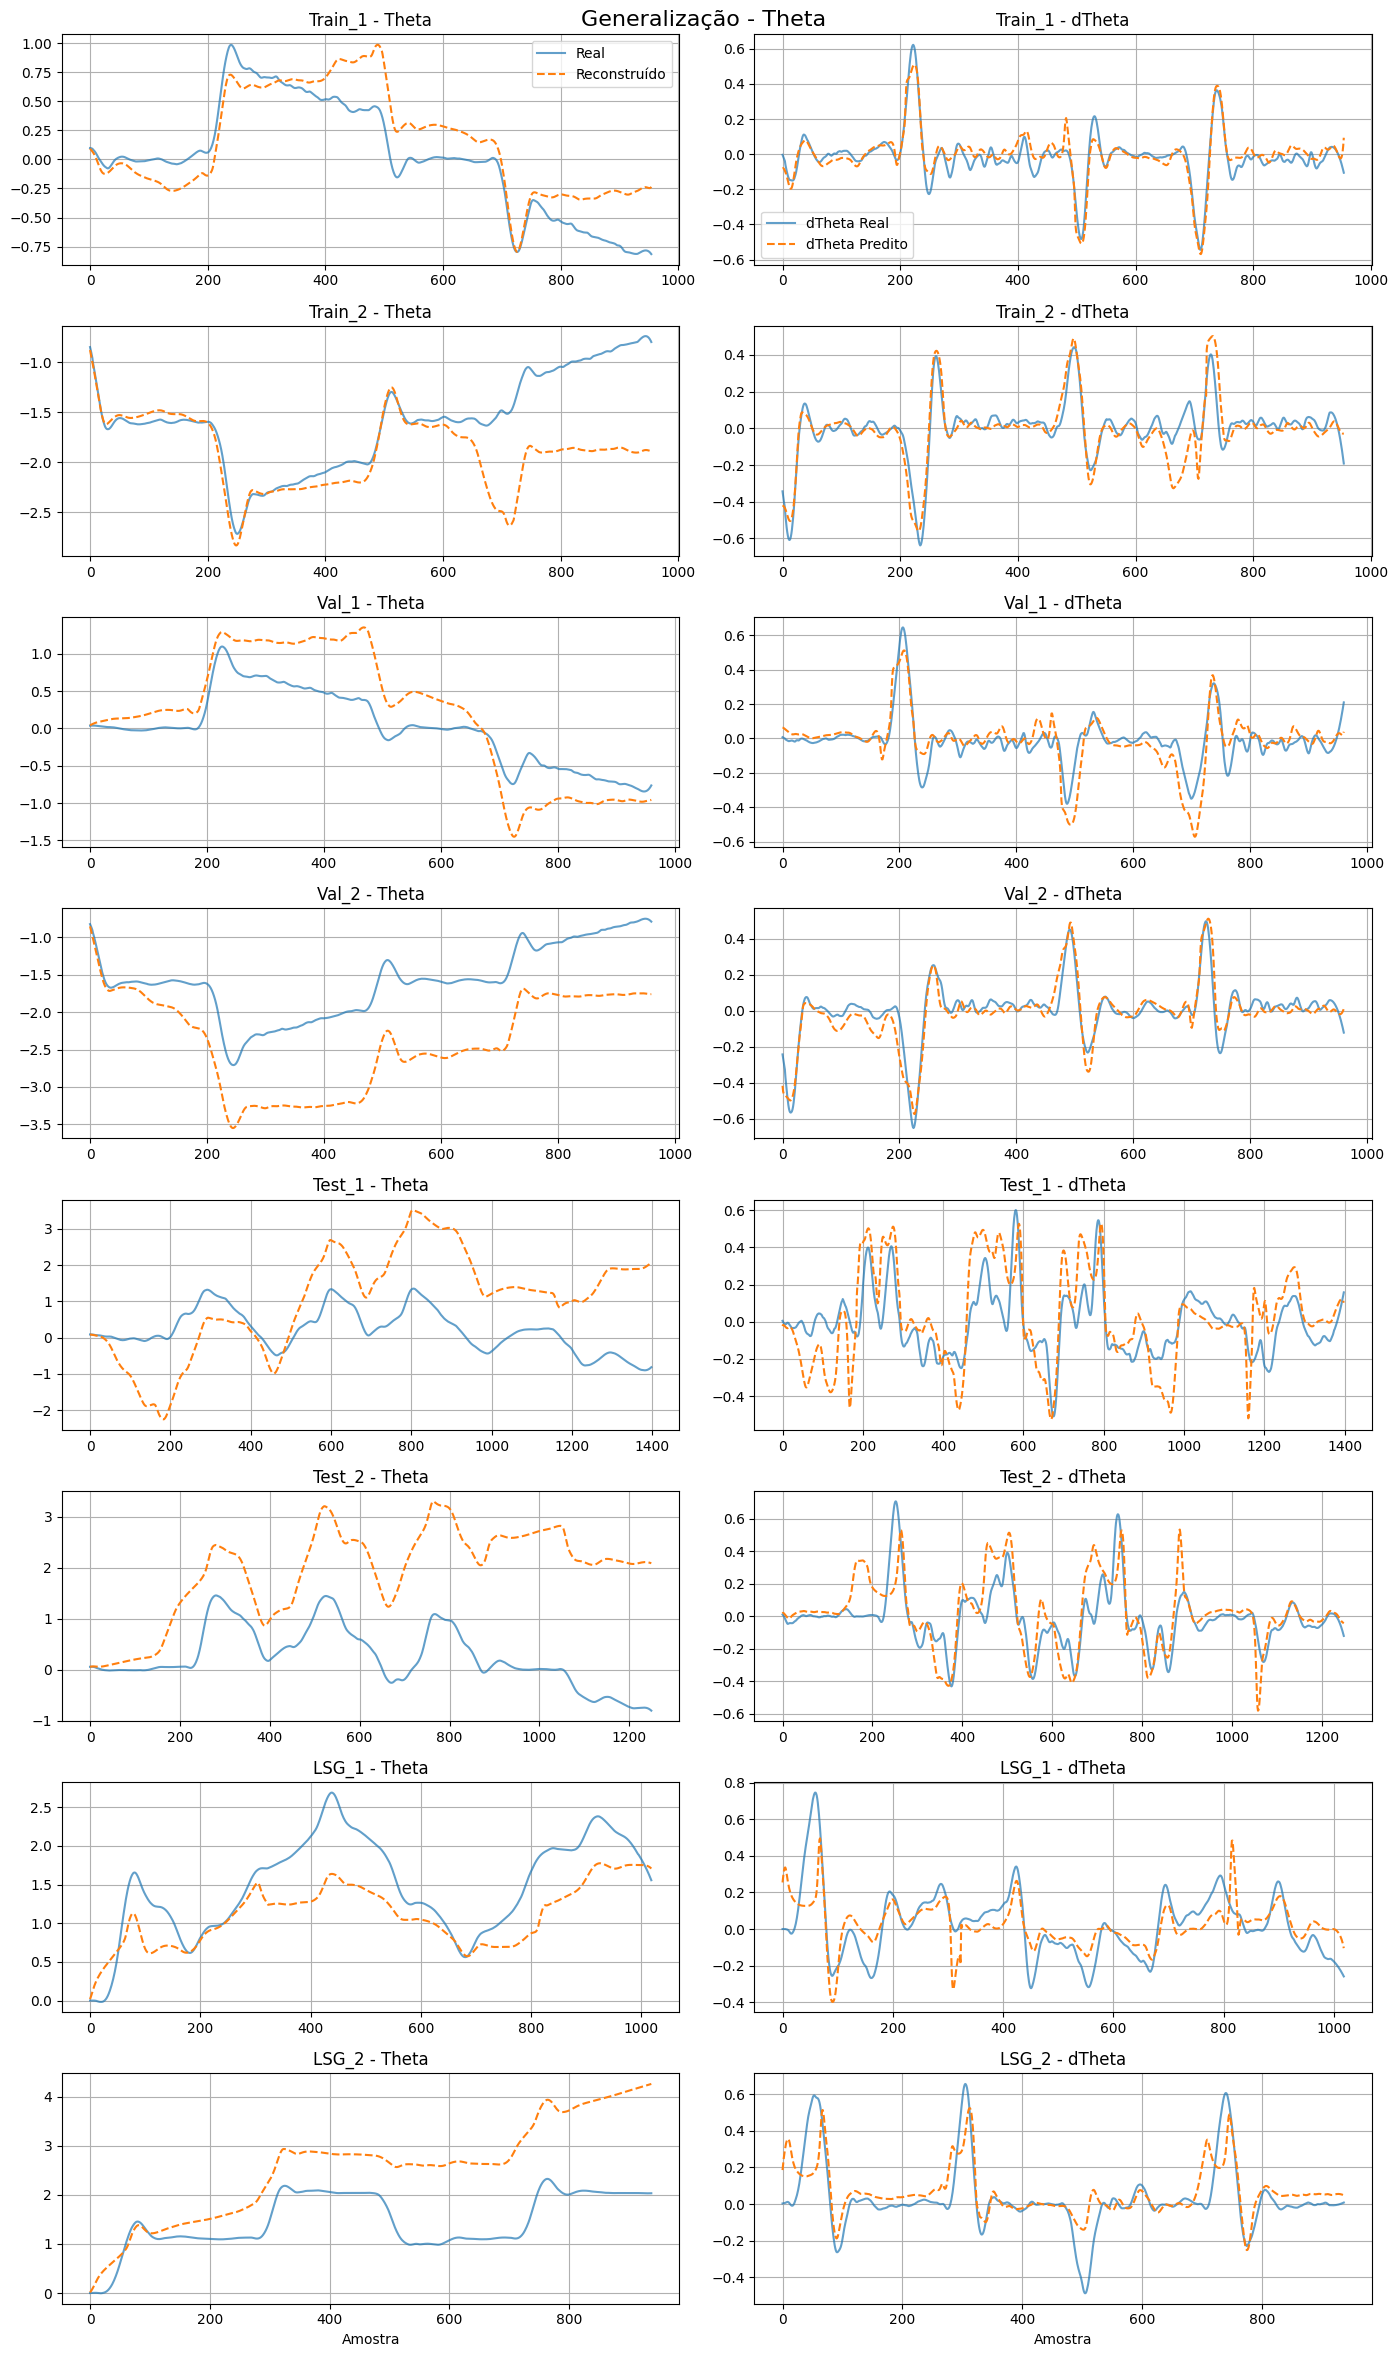

In [ ]:

df = pd.concat([pd.read_excel(DATA_PATH, sheet_name="Train_1"),
               pd.read_excel(DATA_PATH, sheet_name="Train_2")])

Target = df[TARGET_NAME].values
dTarget = df[f"d{TARGET_NAME}"].values

pred_raw = df[PREDICTORS].values

# =========================
# NORMALIZAÇÃO
# =========================
pred_mean = pred_raw.mean(axis=0)
pred_std = pred_raw.std(axis=0) + 1e-8
pred_raw = (pred_raw - pred_mean) / pred_std

y_mean = dTarget.mean()
y_std = dTarget.std() + 1e-8
y_raw = (dTarget - y_mean) / y_std

# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(pred_raw, y_raw, TIME_STEPS)

# =========================
# MODELO (dinâmico)
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, len(PREDICTORS))),
    tf.keras.layers.SimpleRNN(32, activation='tanh'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

# =========================
# TREINO
# =========================
model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2)

# =========================
# FIGURA GERAL
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df = pd.read_excel(DATA_PATH, sheet_name=title)

    Target = df[TARGET_NAME].values
    dTarget = df[f"d{TARGET_NAME}"].values

    pred_raw = df[PREDICTORS].values

    # normalização treino
    pred_raw = (pred_raw - pred_mean) / pred_std
    y_raw = (dTarget - y_mean) / y_std

    X_test, y_test = create_sequences(pred_raw, y_raw, TIME_STEPS)

    # predição
    y_pred = model.predict(X_test, verbose=0)

    y_pred = y_pred * y_std + y_mean
    y_true = y_test * y_std + y_mean

    # =========================
    # RECONSTRUÇÃO 
    # =========================
    Target_true = Target[TIME_STEPS:]
    Target_rec = np.zeros_like(y_pred.flatten())
    y_pred_flat = y_pred.flatten()
    Target_rec = Target_true[0] + np.cumsum(y_pred_flat * TS)

    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Target_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Target_rec, label="Reconstruído", linestyle='--')

    axs[i, 0].set_title(f"{title} - {TARGET_NAME}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(y_true, label=f"d{TARGET_NAME} Real", alpha=0.7)
    axs[i, 1].plot(y_pred, label=f"d{TARGET_NAME} Predito", linestyle='--')

    axs[i, 1].set_title(f"{title} - d{TARGET_NAME}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
        
    r2_dtarget = r2_score(y_true.flatten(), y_pred.flatten())
    r2_target  = r2_score(Target_true.flatten(), Target_rec.flatten())
    print(f"{title} | R2 dtarget: {r2_dtarget:.4f} | R2 Theta: {r2_target:.4f}")

axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET_NAME}", fontsize=16)
plt.tight_layout()
plt.show()
